## Phase 1 Mass Analysis

In [18]:
    library(lme4) #for linear mixed effects model
    library(readr) #to read in data
    library(emmeans) #for post hocs
    library(esquisse) #interface for building plots
    library(dplyr) #for data wrangling
    library(nlme) #for linear mixed effects model
    library(car) #for the Levene test
    library(ggplot2) #for graphs
    library(plotrix) #for standard error
    library(performance) #model testing
    library(lmtest) #another option than levene test for variance

In [19]:
getwd()

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Weight_Data"

In [33]:
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")

### Read in data

In [38]:
Growth_Data_forR <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Ratio_tissue_shell_mg = col_double(),
                                              Phase1_Phase2_rep = col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor()))

### Filter to not include data from dead oysters/ doubles in analysis
  ### Excludes doubles but keeps oysters that died in the second phase, as all oysters were alive for first measurements

In [39]:
Growth_Data_forR_pre <- Growth_Data_forR %>%
  filter(Exclude_pre_analysis != "Y" | is.na(Exclude_pre_analysis)) %>%
  mutate(prop_tissue_growth = Actual_tissue_growth_mg / Actual_tissue_pre_mg,
         prop_shell_growth = Actual_shell_growth_mg / Actual_shell_pre_mg,
         meat_yield = (Actual_tissue_pre_mg/(Dry_weight_pre)))

## Effect of phase 1, TISSUE

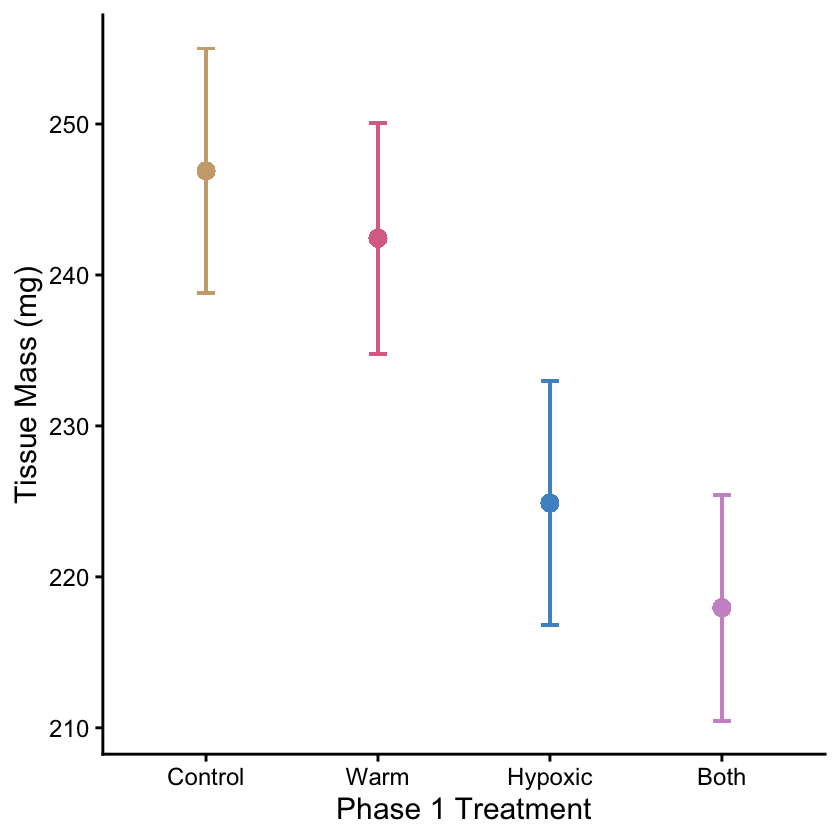

In [48]:
pre_summary_stats_t <- Growth_Data_forR_pre %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_pre = mean(Actual_tissue_pre_mg, na.rm = TRUE),
    se_pre = std.error(Actual_tissue_pre_mg, na.rm = TRUE))

  #reorder effect of phase 1 Phase_1_treat
  pre_summary_stats_t$Phase_1_treat <- factor(pre_summary_stats_t$Phase_1_treat, 
                                            levels = c("Cont", "Warm","Hyp", "Both"))
  #plot TISSUE
  ggplot(pre_summary_stats_t, aes(x = Phase_1_treat, y = mean_pre, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                  width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18)+
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Tissue Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend


## only plotting significant factors / interactions

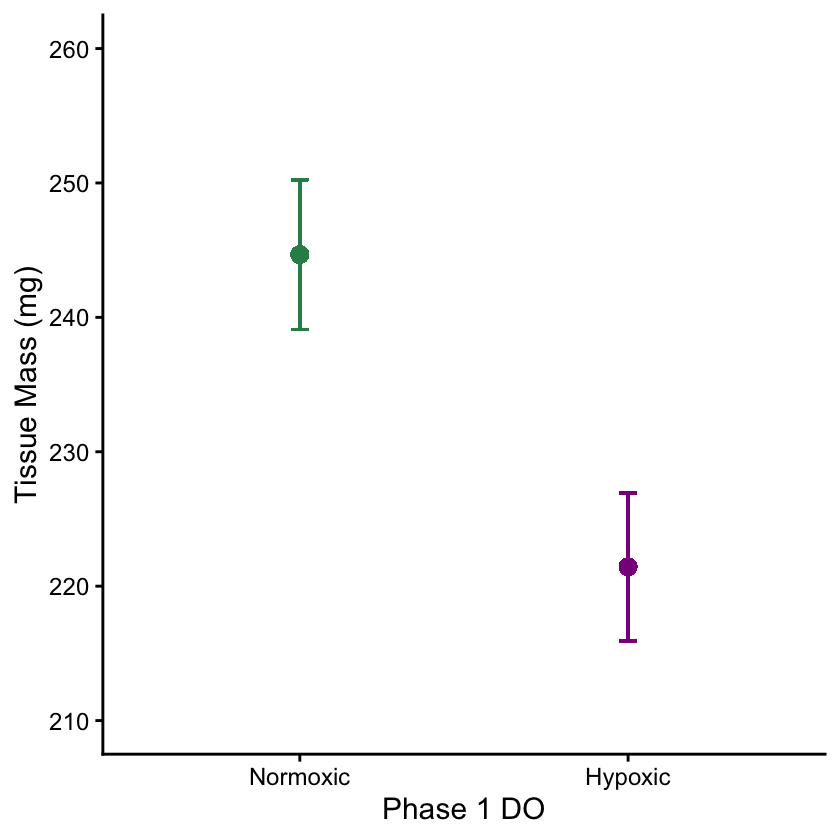

In [55]:
pre_summary_stats_t <- Growth_Data_forR_pre %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_pre = mean(Actual_tissue_pre_mg, na.rm = TRUE),
    se_pre = std.error(Actual_tissue_pre_mg, na.rm = TRUE))
#reorder
pre_summary_stats_t$Phase_1_DO <- factor(pre_summary_stats_t$Phase_1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(pre_summary_stats_t, aes(x = Phase_1_DO, y = mean_pre, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 1 DO", y = "Tissue Mass (mg)") +
  ylim(210,260)+
  theme(legend.position = "none") # Remove legend

Oysters in hypoxia had significantly less tissue mass than oysters in normoxia (p = 0.01)

# Effect of phase 1 data, SHELL

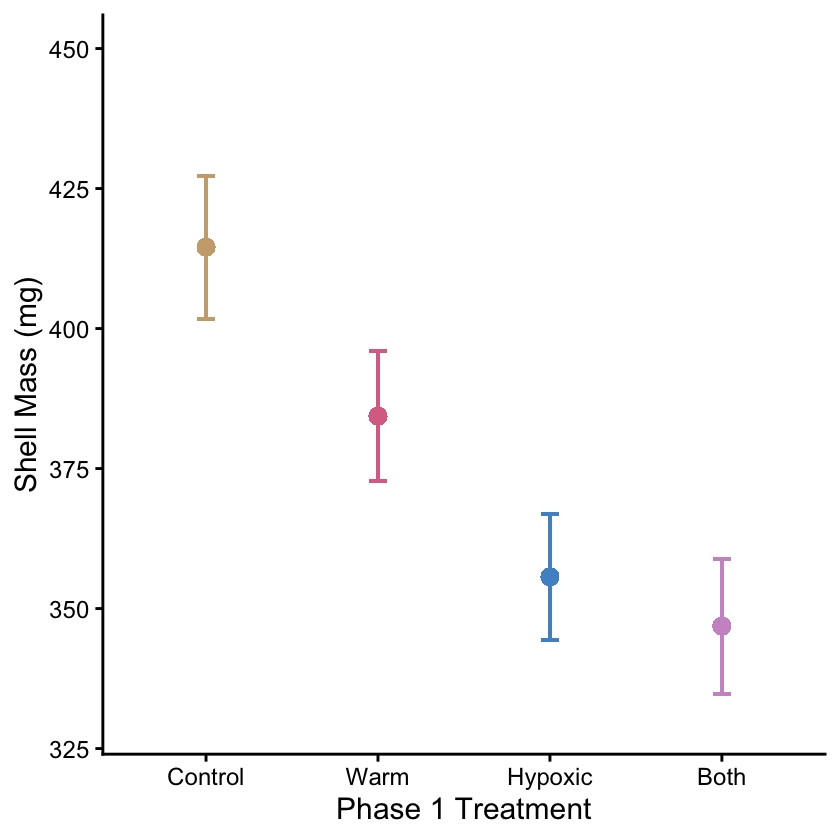

In [66]:

pre_summary_stats_s <- Growth_Data_forR_pre %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_pre = mean(Actual_shell_pre_mg, na.rm = TRUE),
    se_pre = std.error(Actual_shell_pre_mg, na.rm = TRUE))

  #reorder effect of phase 1 Phase_1_treat
  pre_summary_stats_s$Phase_1_treat <- factor(pre_summary_stats_s$Phase_1_treat, 
                                            levels = c("Cont", "Warm","Hyp",  "Both"))
  
  #plot SHELL
  ggplot(pre_summary_stats_s, aes(x = Phase_1_treat, y = mean_pre, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                  width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18)+
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Shell Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    ylim(330, 450)+
    theme(legend.position = "none") # Remove legend

## Only plotting significant factors / interactions

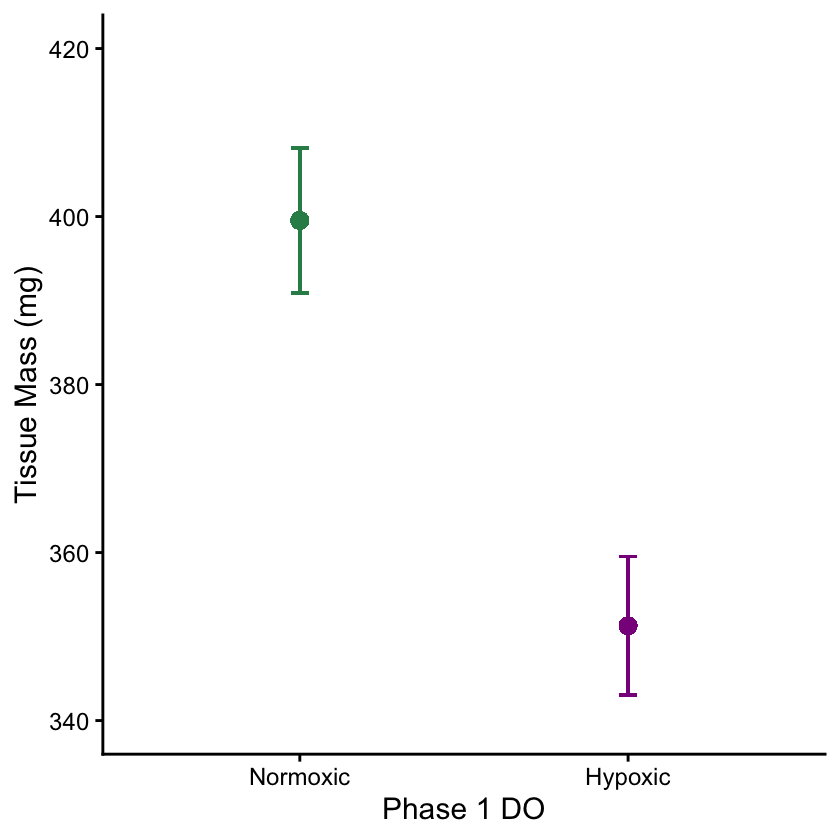

In [68]:
pre_summary_stats_s <- Growth_Data_forR_pre %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_pre = mean(Actual_shell_pre_mg, na.rm = TRUE),
    se_pre = std.error(Actual_shell_pre_mg, na.rm = TRUE))
#reorder
pre_summary_stats_s$Phase_1_DO <- factor(pre_summary_stats_s$Phase_1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(pre_summary_stats_s, aes(x = Phase_1_DO, y = mean_pre, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 1 DO", y = "Tissue Mass (mg)") +
ylim(340, 420)+
  theme(legend.position = "none") # Remove legend

Oysters in hypoxia had significantly less shell mass than oysters in normoxia (p < 0.01)

# Effect of phase 1 data, T:S

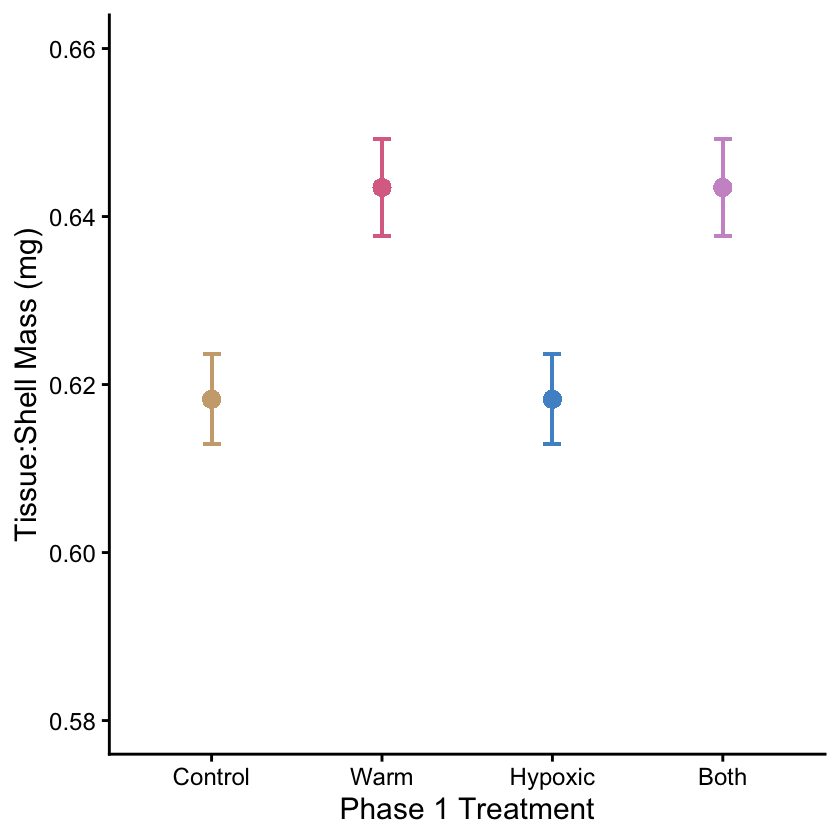

In [54]:
pre_summary_stats_t_s <- Growth_Data_forR_pre %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_pre = mean(Ratio_tissue_shell_pre_mg, na.rm = TRUE),
    se_pre = std.error(Ratio_tissue_shell_pre_mg, na.rm = TRUE))

  #reorder effect of phase 1 Phase_1_treat
  pre_summary_stats_t_s$Phase_1_treat <- factor(pre_summary_stats_t_s$Phase_1_treat, 
                                              levels = c("Cont", "Warm","Hyp",  "Both"))
  
  #plot with mean and SD, T:S
  ggplot(pre_summary_stats_t_s, aes(x = Phase_1_treat, y = mean_pre, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                  width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18) +
    guides(color = "none") + # Remove legend for color
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Tissue:Shell Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    ylim(0.58, 0.66)+
    theme(legend.position = "none") # Remove legend

## Significant factors / interactions, T:S

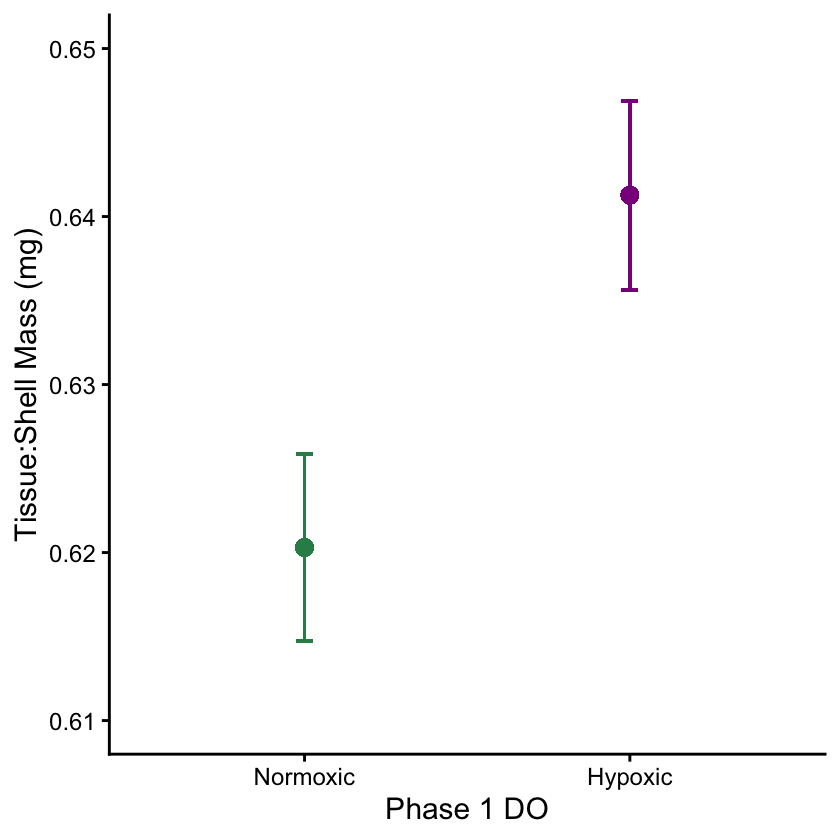

In [69]:
pre_summary_stats_t_s <- Growth_Data_forR_pre %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_pre = mean(Ratio_tissue_shell_pre_mg, na.rm = TRUE),
    se_pre = std.error(Ratio_tissue_shell_pre_mg, na.rm = TRUE))

pre_summary_stats_t_s$Phase_1_DO <- factor(pre_summary_stats_t_s$Phase_1_DO, 
                                         levels = c("Norm", "Hyp"))
#Tissue:Shell plot with mean and SD
ggplot(pre_summary_stats_t_s, aes(x = Phase_1_DO, y = mean_pre, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "Tissue:Shell Mass (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  ylim(0.61, 0.65)+
  theme(legend.position = "none") # Remove legend

Oysters in hypoxia tended to have more tissue:shell than oysters in normoxia (p = 0.58)

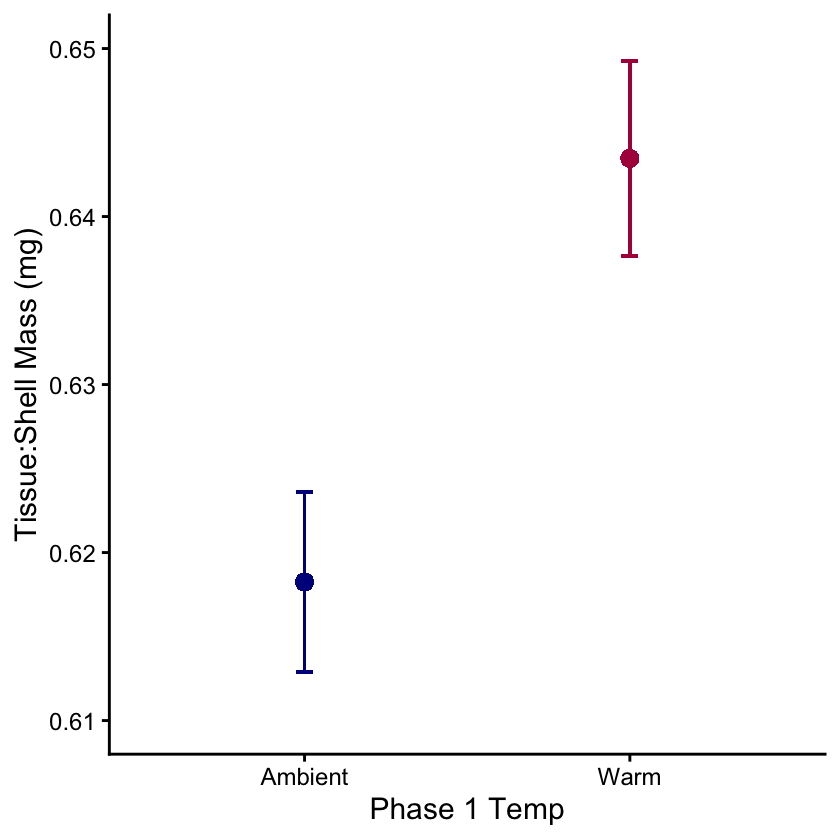

In [74]:
pre_summary_stats_t_s <- Growth_Data_forR_pre %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_pre = mean(Ratio_tissue_shell_pre_mg, na.rm = TRUE),
    se_pre = std.error(Ratio_tissue_shell_pre_mg, na.rm = TRUE))

pre_summary_stats_t_s$Phase_1_temp <- factor(pre_summary_stats_t_s$Phase_1_temp, 
                                           levels = c("Ambient", "Warm"))
#Tissue:Shell plot with mean and SD
ggplot(pre_summary_stats_t_s, aes(x = Phase_1_temp, y = mean_pre, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temp", y = "Tissue:Shell Mass (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  ylim(0.61, 0.65)+
  theme(legend.position = "none") # Remove legend

Oysters in warm environments had significantly more tissue:shell than oysters in normoxia (p = 0.02)